# 0. Präambel

Group 8: 
Yuetong Jin
Simon Andres
Christopher Forschner
Felix Bunse
Janik Müller

Here we are going to define the important packages and the stuff that we need in order to start the project.

In [1]:
# Importing the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data

In [2]:
# DOWNLOAD DATA

# only change the equity ticker strings if required
# don't change the variable name "tickers"
tickers = [ \
    'AAPL', # Apple
    'MSFT', # Microsoft
    'AMZN', # Amazon
    '^GSPC'] # S&P500 - Benchmark

# only change string values if required
# don't change the two variable names "start_date" and "end_date"
start_date = '2010-01-01'
end_date = '2021-12-31'

# download the time series of adj. close price
# for each of the tickers from Yahoo finance
# in case you receive an error go through this:
## https://stackoverflow.com/questions/74832296/typeerror-string-indices-must-be-integers-when-getting-data-of-a-stock-from-y
price_data = {}

for ticker in tickers:
    price_data[ticker] = yf.download(ticker, start=start_date, end=end_date)['Adj Close']

# create dataframe with one row per day and adj. close price for each of the tickers
# and dataframe with price changes
df_prices = pd.concat([price_data[ticker].rename(ticker) for ticker in tickers], axis=1)
prev = df_prices.to_numpy()
prev = prev / np.insert(prev[:-1,:], 0, np.ones(prev.shape[1]), 0)
prev[0] = np.ones(prev.shape[1])
df_price_changes = df_prices.copy(deep=True)
df_price_changes[:] = prev

# print dataframes
print(df_prices)
print(df_price_changes)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
                  AAPL        MSFT        AMZN        ^GSPC
Date                                                       
2010-01-04    6.496296   23.572371    6.695000  1132.989990
2010-01-05    6.507526   23.579979    6.734500  1136.520020
2010-01-06    6.404014   23.435272    6.612500  1137.140015
2010-01-07    6.392175   23.191555    6.500000  1141.689941
2010-01-08    6.434672   23.351500    6.676000  1144.979980
...                ...         ...         ...          ...
2021-12-23  174.753906  330.033112  171.068497  4725.790039
2021-12-27  178.768845  337.685150  169.669495  4791.189941
2021-12-28  177.737823  336.501862  170.660995  4786.350098
2021-12-29  177.827072  337.192078  169.201004  4793.060059
2021

## Helper functions - Basic

In [3]:
# DEFINE HELPER FUNCTIONS USED ACROSS SIGNALS (in case needed)

# Moving average
def moving_average(prices, window_length):
    return np.convolve(prices, np.ones(window_length)/window_length, mode='same')

# Standard Deviation
def standard_deviation(prices, window_length):
    avg = moving_average(prices, window_length)
    return np.sqrt(np.convolve((prices - avg)**2, np.ones(window_length)/window_length, mode='same'))


# Calculate the Differnce in Percent

def diff(array): 

    diffs = np.zeros(len(array))
    for i in range(0, len(array)):
        if i == 0:
            diffs[i] = 0
        else:
            diffs[i] = (array[i] - array[i-1]) / array[i-1]
        
    return(diffs)



# Calculate the mean

def mittelwert(array):
    
    # Making sure that the list we calculate is not of length zero 
    if len(array) == 0:
        return None
    else:
        return sum(array) / len(array) # Returning the mean if all the above is incorrect
    
    
# define a helper function for the percental change
def percental_change(cash, window_length):
    cash_np=cash.to_numpy()
    changes=[]
    changes_0=0
    changes.append(changes_0)

    for i in range(1,window_length):
        changes_i=(cash_np[i]-cash[i-1]) * 100 
        changes.append(changes_i)  

    return changes

# 1. Implementing the Trading Signals

In [4]:
# DEFINE THREE TRADING SIGNALS

# DO YOUR RESEARCH IN A SEPARATE NOTEBOOK AND IMPLEMENT THE FINAL SIGNALS HERE
# PLEASE PROVIDE THE FOLLOWING AS PART OF THE ASSESSMENT:
# - provide a reference to the related literature for each trading signal as mentioned below
# - provide your SEPARATE RESERACH NOTEBOOK in which you back your trading signals
#   and their parameters by empirical research; there is no example for your research notebook,
#   you're completely free to build it according to your research

# REMEMBER THAT YOU MAY NOT USE READY-TO-USE FUNCTIONS
# WHEN IN DOUBT - CODE A FUNCTION ON YOUR OWN!
# EXAMPLE: .rolling().mean() is ready-to-use, that's why moving average is implemented below

# PLEASE MAKE SURE THAT YOUR SIGNAL FUNCTIONS DO NOT GENERATE
# SELL SIGNALS WHEN THERE WERE NO BUY SIGNALS BEFORE

# 1.1 MACD-Signal

The Exponetial Moving Average is defined as:
$ EMA_{t}=\alpha P_{t}+(1-\alpha)EMA_{t-1}$

The buying signal is defined by the zero-crossover rule as follows:

$
     zero\ crossover=\left\{\begin{array}{ll} Buy, when\ MACD_{t}\left(t_{1},t_{2}\right)=EMA_{t}\left(t_{1}\right)-EMA_{t}\left(t_{2}\right) >0\\
         Sell, when\ MACD_{t}\left(t_{1},t_{2}\right)=EMA_{t}\left(t_{1}\right)-EMA_{t}\left(t_{2}\right) <0  \end{array}\right.$


In [5]:
#### Helper function ------------------------------------- 

#create exponential weighted moving average function
#pandas had an own ewm function implemented

def ewm_own(x,s):
    #calculate the weights alpha
    alpha=(2/(1+s))
     #convert the series into a numpy array

    #initalize the first EWM
    ewm_0=x[0]

    exp_mean=[]
    exp_mean.append(ewm_0)
    #calculate the EWM for the series
    for i in range(1,len(x)):
        ewm_i=alpha*x[i]+(1-alpha)*exp_mean[i-1]
        exp_mean.append(ewm_i) 
    return exp_mean 

#create a helper function for the trading strategy (cross over strategy)
def strategy(dataset):    
    buy_price = []
    sell_price = []
    macd_signal = []
    signal = 0

    for i in range(len(dataset)):
        if dataset['MADC'][i] > dataset['signal'][i]: #buy at this point
            if signal != 1:
                buy_price.append(dataset['prices'][i])
                sell_price.append(np.nan)
                signal = 1
                macd_signal.append(signal)
            else: #hold
                buy_price.append(np.nan)
                sell_price.append(np.nan)
                macd_signal.append(0)
        elif dataset['MADC'][i] < dataset['signal'][i]: #sell
            if signal != -1:
                buy_price.append(np.nan)
                sell_price.append(dataset['prices'][i])
                signal = -1
                macd_signal.append(signal)
            else: #hold
                buy_price.append(np.nan)
                sell_price.append(np.nan)
                macd_signal.append(0)
        else: #hold
            buy_price.append(np.nan)
            sell_price.append(np.nan)
            macd_signal.append(0)

    #save in data frame
    trading_strategy = pd.DataFrame({
    'Buy Price': buy_price,
    'Sell Price': sell_price,
    'position_change': macd_signal
},index=dataset.index)
    return trading_strategy


In [6]:
### SIGNAL 0
## Appel,G.; Dobson, E. (2008).
# Understanding MACD. 
# Published: Traders Press, Inc. 
# Available at: https://www.scribd.com/document/349277765/Understanding-MACD#


def signal_0(series,short_window = 12, long_window = 26, signal_period = 9):
    # Init
    signals = pd.DataFrame(index = series.index)
    
    # Compute exponential moving average
    signals['prices']=series #the prices
    signals['short_ma'] = ewm_own(series, short_window)
    signals['long_ma'] = ewm_own(series, long_window)
    signals['MADC']=signals['short_ma']-signals['long_ma']
    signals['signal']=ewm_own(signals['MADC'],signal_period)
    signals['histogram']=signals['MADC']-signals['signal']

    #compute the signals and trading strategy
    trading_strategy=strategy(signals)
    signal_df=pd.concat([signals,trading_strategy],axis=1)
    return signal_df

# 1.2 RSI Signal

The Relative Strength Index (RSI) is a popular technical analysis tool used by traders and investors to assess the momentum and strength of a stock's price movement. Developed by J. Welles Wilder in 1978, the RSI is widely employed to identify overbought and oversold conditions in the market, helping traders make informed decisions about potential price reversals or continuations. 
Traders utilize the RSI to identify potential buying or selling opportunities. When the RSI surpasses a threshold of 70, it suggests that the asset is overbought, indicating a possible price correction. Conversely, when the RSI falls below a threshold of 30, it indicates that the asset is oversold, potentially signaling a price rebound.

The RSI measures the magnitude of recent price changes and compares the number of days an asset closed higher to the number of days it closed lower. This comparison is then expressed as a numerical value ranging from 0 to 100. The RSI is typically calculated over a defined period, commonly 14 days, although shorter or longer timeframes can be used depending on the trader's preferences and the asset being analyzed.

The RSI's formula is based on a relatively straightforward calculation that involves three key steps. First, the average gain and average loss over the specified period are computed. The average gain is the sum of all positive price changes divided by the period, while the average loss is the sum of all negative price changes divided by the period. Next, the relative strength (RS) is determined by dividing the average gain by the average loss. Finally, the RSI itself is calculated using the following formula:

$ RSI = 100 - \frac{100}{(1 + RS)} $

Overall, the Relative Strength Index (RSI) provides traders with a straightforward and effective tool for assessing the momentum and potential overbought or oversold conditions of an asset, aiding in the identification of trading opportunities within the financial markets.

In [7]:
### RSI
## related literature:
# Marek,P; Sediva,B. (2017). 
# Optimizing and Testing of RSI. 
# Published: 11th International Scientific Conference on Financial Management of Firms and Financial Institutions. 
# Available at: https://www.researchgate.net/publication/322209653_Optimization_and_Testing_of_RSI

# Ng,W; Liew, K; Chong, T. (2014). 
# Revisiting the Performance of MACD and RSI oscillators. 
# Published in Journal of Risk and Financial Management. Volume 7. pp. 1-12. 
# Available at: https://www.mdpi.com/1911-8074/7/1/1

# Calculate RSI function

def calculate_rsi(prices, period = 14):

    # Calculate the difference between two adjacent prices
    differences = np.diff(prices)
    
    # Create two copies of the differences: One for the up movements and one for the down movements
    positive_differences = differences.copy()
    negative_differences = differences.copy()
    
    # Set all the values below zero in the positive differences array and all the values above zero in the negative differences array to zero
    positive_differences[positive_differences < 0] = 0
    negative_differences[negative_differences > 0] = 0
    
    # Calculate the average gain and loss for the first observation
    average_gain = mittelwert(positive_differences[:period])
    average_loss = -mittelwert(negative_differences[:period])
    
    # Initialize the rsi_values list to store all the coming rsi_values to speed up the code
    rsi_values = np.zeros(len(prices))

    # Calculate the average gain and losses for the the rest of the periods
    for i in range(period, len(prices)):
        current_differences = differences[i - 1]
        if current_differences > 0:
            average_gain = (average_gain * (period - 1) + current_differences) / period
            average_loss = (average_loss * (period - 1)) / period
        else:
            average_gain = (average_gain * (period - 1)) / period
            average_loss = (average_loss * (period - 1) - current_differences) / period
        rs = average_gain / average_loss
        rsi = 100.0 - (100.0 / (1.0 + rs))
        rsi_values[i] = rsi
        rsi_values[rsi_values == 0] = np.nan

    return rsi_values.tolist()

### Calculating the RSI - Signal

def signal_1(data, window = 14, upper_bound = 70, lower_bound = 30):
    
    data_rsi = pd.DataFrame(index = data.index)
    
    data_rsi['Close Price'] = data
    
    # Calculate RSI for the observed stock data
    data_rsi['rsi_values'] = calculate_rsi(data_rsi['Close Price'], window)

    # Generate a list to store the position changes according to RSI values
    position_change = [0] * len(data_rsi['Close Price'])
    
    
    # Ensure that there are no sell signals before a buy signal and that the first signal is a buy signal
    # Initial value of holding stock is 'no'
    holding = 'no'
    
    for i in range(len(data)):
        if data_rsi['rsi_values'][i] < lower_bound and holding == 'no': # this is our buy condition
            
            position_change[i] = 1 # adjusting position change to 1
            holding = 'yes' # changing the holding parameter to: 'yes'
            
        elif data_rsi['rsi_values'][i] > upper_bound and holding == 'yes': # this is our sell condition
            
            position_change[i] = -1 # adjusting the position to -1
            holding = 'no'# changing the holding parameter to: 'no'
            
        else:
            position_change[i] = 0 # here we just make sure, that all other values are zeros
            
    data_rsi['position_change'] = position_change
    
    # Signal Column -> when to buy and sell
    
    data_rsi['signal_buy'] = np.where(data_rsi['rsi_values'] < lower_bound, 1, 0)
    data_rsi['signal_sell'] = np.where(data_rsi['rsi_values'] > upper_bound, -1, 0)
            
    # Signal that says when we hold the asset - 'Position Open'
    
    data_rsi['signal'] = np.cumsum(data_rsi['position_change'])

    return data_rsi


## 1.3 Bollinger Bands

The last signal is based on Bollinger Bands. For computing the upper and lower band we are using the common standard deviation multiplier of 2.

The trading rules for this signal are as follows: <br> 
 &nbsp;&nbsp;&nbsp;&nbsp;If $p_{N}(t-1)<  BB_{N}^{low}(t-1) $ and $p_{N}(t)>  BB_{N}^{low}(t) $ , a long position is initiated on the next day's opening. <br>
 &nbsp;&nbsp;&nbsp;&nbsp;When $p_{N}(t)> SMA_{N}(t) $ , the long position closes on the next day's opening. <br>
 
Where:
$$
SMA_{N}(t)=\frac{\sum_{i=t-t-N+1}^{t}p(i)}{N}
$$
$$
BB_{N}^{high}(t)=SMA_{N}(t)+k\times \sqrt{\frac{\sum_{i=t-N+1}^{t}[p(i)-SMA_{N}(i)]^{2}}{N}} 
$$
$$
BB_{N}^{low}(t)=SMA_{N}(t)-k\times\sqrt{\frac{\sum_{i=t-t-N+1}^{t}[p(i)-SMA_{N}(i)]^{2}}{N}}
$$  

In [8]:
### Bollinger Bands
## Bollinger, J. (1992). 
# Using Bollinger Bands. 
# [online] pp.47–51. 
# Available at: https://c.mql5.com/forextsd/forum/211/Using%20Bollinger%20Bands%20by%20John%20Bollinger.pdf.

def signal_2(series, window_length=20, num_std=2):

    # Compute middle band (SMA), upper band and lower band
    rolling_mean = moving_average(series, window_length)
    rolling_std  = standard_deviation(series, window_length)
    upper_band = rolling_mean + (rolling_std*num_std)
    lower_band = rolling_mean - (rolling_std*num_std)

    # Create a DataFrame to store all data
    signals = pd.DataFrame(index=series.index)
    signals['Middle Band'] = rolling_mean
    signals['Upper Band'] = upper_band
    signals['Lower Band'] = lower_band
    
    # Create signals based on Bollinger Bands and SMA
    # We make sure not to generate sell signals before a buy signal
    signals['signal'] = 0.0
    holding = False
    for i in range(window_length, len(series) - 1):  # Need to look ahead 1 day, so stop loop 1 day early
        # If price crosses above the lower band, we enter a position
        if not holding and series[i-1] <= lower_band[i-1] and series[i] > lower_band[i]:
            signals['signal'][i+1] = 1.0
            holding = True
        # If we are holding a position and price crosses above the SMA from below, we exit the position
        elif holding and series[i-1] <= rolling_mean[i-1] and series[i] > rolling_mean[i]:
            signals['signal'][i+1] = 0.0
            holding = False
        # If we are holding a position and price doesn't cross above the SMA, we hold the position
        elif holding and series[i] <= rolling_mean[i]:
            signals['signal'][i+1] = 1.0

    signals['position_change'] = signals['signal'].diff()
    signals.loc[series.index[0], 'position_change'] = 0
    
    return signals

# 1.4 Combining the Signals

In [9]:
# Compute signals
signals = {}
signals[tickers[0]] = signal_0(df_prices[tickers[0]])
signals[tickers[1]] = signal_1(df_prices[tickers[1]])
signals[tickers[2]] = signal_2(df_prices[tickers[2]])
df_position_open = pd.concat([
    signals[tickers[0]]['signal'].rename(tickers[0]),
    signals[tickers[1]]['signal'].rename(tickers[1]),
    signals[tickers[2]]['signal'].rename(tickers[2])], axis = 1)
df_position_changes = pd.concat([
    signals[tickers[0]]['position_change'].rename(tickers[0]),
    signals[tickers[1]]['position_change'].rename(tickers[1]),
    signals[tickers[2]]['position_change'].rename(tickers[2])], axis = 1)

# 2. Portfolio Building and Portfolio Analysis

In [10]:
# ALLOCATE CAPITAL AND COMPUTE RESULTING POSITIONS
initial_cash = 1.0
capital_fraction_per_trade = 0.35

# DO NOT MODIFY THIS CELL BELOW THIS LINE
position = []

def open_trades(position, position_change):
    vec = np.maximum([position_change[ticker] for ticker in tickers[:-1]], [0])
    vec = position[-1] * (1 - np.power((1 - capital_fraction_per_trade), np.sum(vec))) * vec / (1 if (np.nansum(vec) == 0.0) else np.nansum(vec))
    return np.append(vec + position[:-1], position[-1] - np.sum(vec))

def hold_trades(position, price_change):
    return np.concatenate((position[:-1] * price_change[:-1], [position[-1]]))

def close_trades(position, position_change):
    vec = np.concatenate((np.array([position_change[ticker] < 0.0 for ticker in tickers[:-1]]), [False]))
    position[-1] = position[-1] + np.sum(position[vec])
    position[vec] = 0.0
    return position
    
is_first = True
for idx, position_change in df_position_changes.iterrows():
    if is_first:
        position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
        is_first = False
    else:
        hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
        hlpr_pos = close_trades(hlpr_pos, position_change)
        position.append(open_trades(hlpr_pos, position_change))

df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])

In [11]:
# COMPUTE MEANINGFUL STATISTICS OF YOUR STRATEGY
# YOU ARE FREE TO CHOOSE MEASURES

# REMEMBER THAT YOU MAY NOT USE READY-TO-USE FUNCTIONS
# WHEN IN DOUBT - CODE A FUNCTION ON YOUR OWN!
# EXAMPLE: .mean() and .std() are ready-to-use, that's why they are implemented below

returns = df_position.sum(axis=1)
returns = (returns[1:].to_numpy() / returns[:-1].to_numpy()) - 1
mean_returns = np.sum(returns) / len(returns)
std_returns = np.sqrt(np.sum(np.square(returns - mean_returns)) / len(returns))
print('Annualized mean: ' + str(mean_returns * 250))
print('Annualized std:  ' + str(std_returns * np.sqrt(250)))

Annualized mean: 0.1327835213949398
Annualized std:  0.0731161877509002


# 2.1 Sharpe and Sortino Ratio

## 2.1.1 Sharpe Ratio

In [12]:
def calculate_sharpe_ratio(mean_returns, std_returns, risk_free_rate, num_periods):
    annualized_mean = mean_returns * num_periods
    annualized_std = std_returns * np.sqrt(num_periods)
    return (annualized_mean - risk_free_rate) / annualized_std

risk_free_rate = 0.01  # 1% risk-free rate
num_periods = 250

sharpe = calculate_sharpe_ratio(mean_returns, std_returns, risk_free_rate, num_periods)
print('Sharpe Ratio: ' + str(sharpe))

Sharpe Ratio: 1.679293261476534


## 2.1.2 Sortino Ratio

In [13]:
# Sortino Ratio function

def calculate_sortino_ratio(returns, risk_free_rate):
    # Filter all the negative returns for the ratio
    negative_returns = returns[returns < 0]
    
    # Calculate the mean from all returns
    mean_return = mittelwert(returns)
    
    # Calculate the downward standard deviation
    downside_deviation = np.sqrt(mittelwert((negative_returns - mean_return)**2))
    
    # Calculate the annulized mean return and the annualized downward deviation
    annualized_mean_return = mean_return * 250
    annualized_downside_deviation = downside_deviation * np.sqrt(250)
    
    # Calculate the Sortino Ratio
    sortino_ratio = (annualized_mean_return - risk_free_rate) / annualized_downside_deviation
    
    return sortino_ratio

risk_free_rate = 0.01

# Sortino Ratio Calculation

sortino_ratio = calculate_sortino_ratio(returns, risk_free_rate)
print('Sortino Ratio: ' + str(sortino_ratio) + ' for a risk-free rate of ' + str(risk_free_rate * 100) + '%.')

Sortino Ratio: 1.346495860025837 for a risk-free rate of 1.0%.


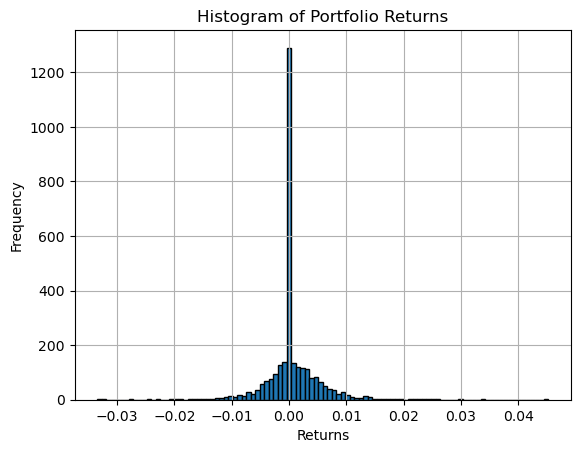

In [14]:
# PLot to explain the difference between Sharpe and Sortino Ratios

# Sharpe Ratio is higher because we have a lot of observations around the zero which reduces our overall volatility from our portfolio.
# The downward volatility is therefore higher than our overall volatility which explains why we have a higher sharpe than Sortino ratio

plt.hist(returns, bins=100, edgecolor='black')  # Adjust the number of bins as needed
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.title('Histogram of Portfolio Returns')
plt.grid(True)
plt.show()

## 2.2 Maximum Drawdown

In [15]:
def calculate_max_drawdown(returns):

    # Calculate cumulative returns
    # We start at 1 (100%) and iteratively multiply by the growth factor of each return
    cumul_returns = [1 + returns[0]]
    for i in range(1, len(returns)):
        cumul_returns.append(cumul_returns[i-1] * (1 + returns[i]))
    cumul_returns = np.array(cumul_returns)
    
    # Calculate the running maximum of the cumulative returns (the peak to this point)
    peak = [cumul_returns[0]]
    for i in range(1, len(cumul_returns)):
        peak.append(max(peak[i-1], cumul_returns[i]))
    peak = np.array(peak)
    
    # Calculate drawdowns (percentage drop from the peak to the current value)
    drawdown = (peak - cumul_returns) / peak
    
    max_drawdown = np.max(drawdown)
    
    return max_drawdown

max_drawdown = calculate_max_drawdown(returns)

print('Max Drawdown: ' + str(max_drawdown))

Max Drawdown: 0.0922649558241049


## 2.3 Value at Risk

In [16]:
# Value at Risk

def calculate_var(returns, confidence_level = 0.95):
    sorted_returns = np.sort(returns)
    var_index = int((1 - confidence_level) * len(sorted_returns))
    var = sorted_returns[var_index]
    return var

confidence_level = 0.95
value_at_risk = calculate_var(returns, confidence_level)

print('Using the historical simulation approach we calculate the daily value at risk at: ' + str(np.round(value_at_risk, 4) * 100) + '% for a confidence level of ' + str(confidence_level * 100) + '%.')

Using the historical simulation approach we calculate the daily value at risk at: -0.59% for a confidence level of 95.0%.


## 2.4 Backtesting

C:\Users\janik\AppData\Local\Temp\ipykernel_22612\2572719783.py:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
C:\Users\janik\AppData\Local\Temp\ipykernel_22612\2572719783.py:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


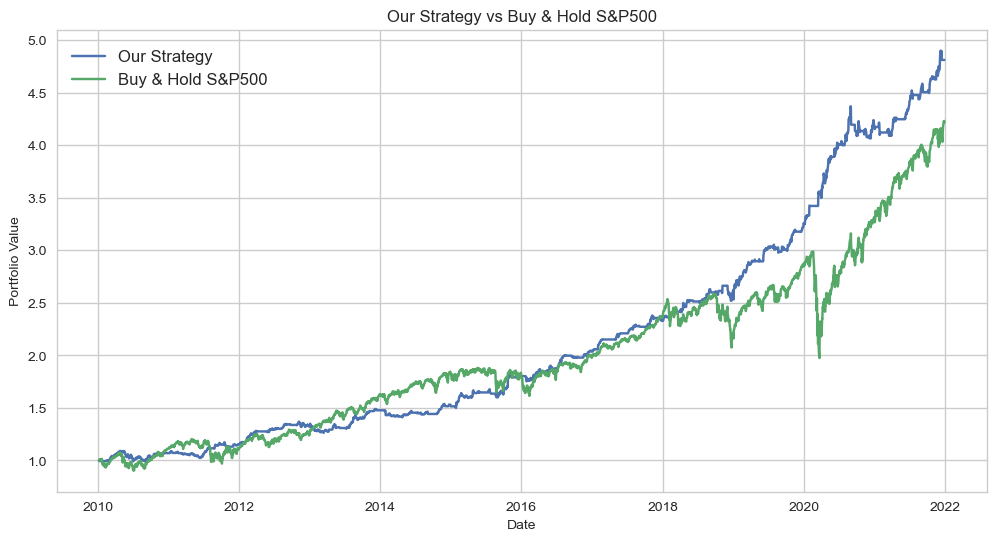

In [17]:
#### BACKTESTING: Comparison with Buy & hold strategy of S&P500

# We use all our cash to buy the S&P500 at the start
# To simplify things slightly, we assume we can buy
# small fractions of a share
initial_sp500_price = df_prices['^GSPC'][0]
num_shares_bought = initial_cash / initial_sp500_price

# Calculate daily portfolio value
bh_portfolio_value = num_shares_bought * df_prices['^GSPC']

# Plotting the buy & hold strategy against our strategy
plt.style.use('seaborn')
plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(12,6))
plt.plot(df_position.sum(axis=1), label='Our Strategy')
plt.plot(bh_portfolio_value, label='Buy & Hold S&P500')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.title('Our Strategy vs Buy & Hold S&P500')
plt.legend(fontsize = 'large', loc = 'upper left', bbox_to_anchor=(0.00, 0.99))
plt.show()

## 2.5 Performance Measures - Comparison

In [18]:
def calculate_performance_measures(returns, risk_free_rate):
    
    num_periods = 250
    
    # Compute annualized returns and standard deviation
    mean_returns = np.sum(returns) / len(returns)
    std_returns = np.sqrt(np.sum(np.square(returns - mean_returns)) / len(returns))
    
    # Compute Sharpe Ratio   
    sharpe_ratio = calculate_sharpe_ratio(mean_returns, std_returns, risk_free_rate, num_periods)

    # Compute Sortino Ratio
    sortino_ratio = calculate_sortino_ratio(returns, risk_free_rate)

    # Compute Maximum Drawdown
    max_drawdown = calculate_max_drawdown(returns)
    
    # Value at Risk
    var = calculate_var(returns)
    
    return {
        'Annualized Mean': mean_returns * num_periods,
        'Annualized Std.': std_returns * np.sqrt(num_periods),
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Max Drawdown': max_drawdown,
        'Value At Risk': var
    }

# Calculate returns for buy & hold
bh_portfolio_value = bh_portfolio_value.to_numpy()
bh_returns = bh_portfolio_value[1:] / bh_portfolio_value[:-1] - 1

# Calculate statistics
risk_free_rate = 0.01
strategy_stats = calculate_performance_measures(returns, risk_free_rate)
bh_stats = calculate_performance_measures(bh_returns, risk_free_rate)

# Comparison in Dataframe
df_stats = pd.DataFrame({'Our Strategy': strategy_stats, 'Buy & Hold S&P500': bh_stats})
df_stats

,Our Strategy,Buy & Hold S&P500
Annualized Mean,0.132784,0.133910
Annualized Std.,0.073116,0.171025
Sharpe Ratio,1.679293,0.724512
Sortino Ratio,1.346496,0.655991
Max Drawdown,0.092265,0.339250
Value At Risk,-0.005893,-0.016214


## 2.6 Portfolio Analysis

C:\Users\janik\AppData\Local\Temp\ipykernel_22612\4030813748.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
C:\Users\janik\AppData\Local\Temp\ipykernel_22612\4030813748.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


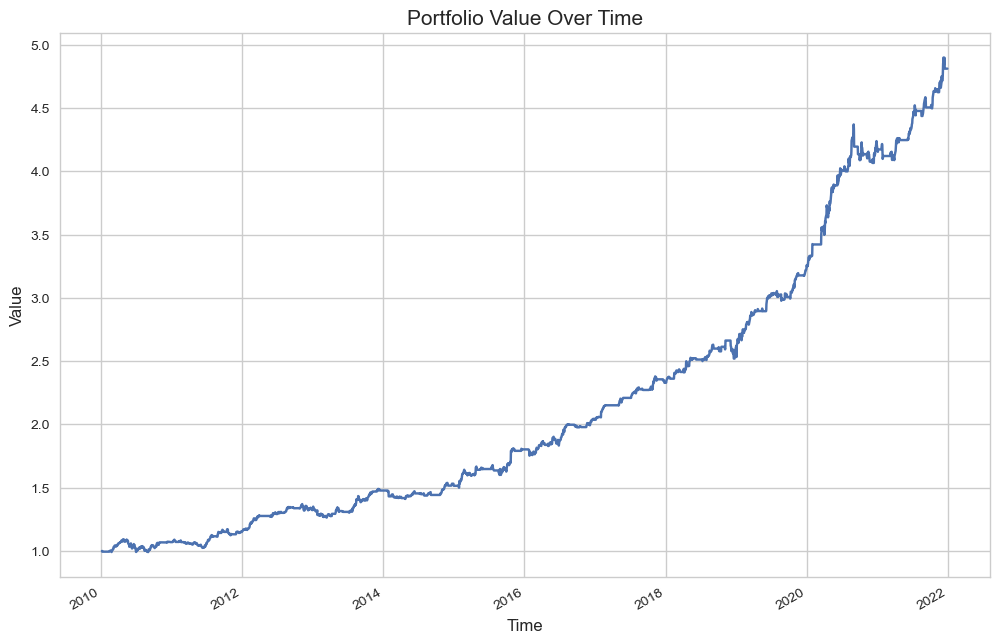

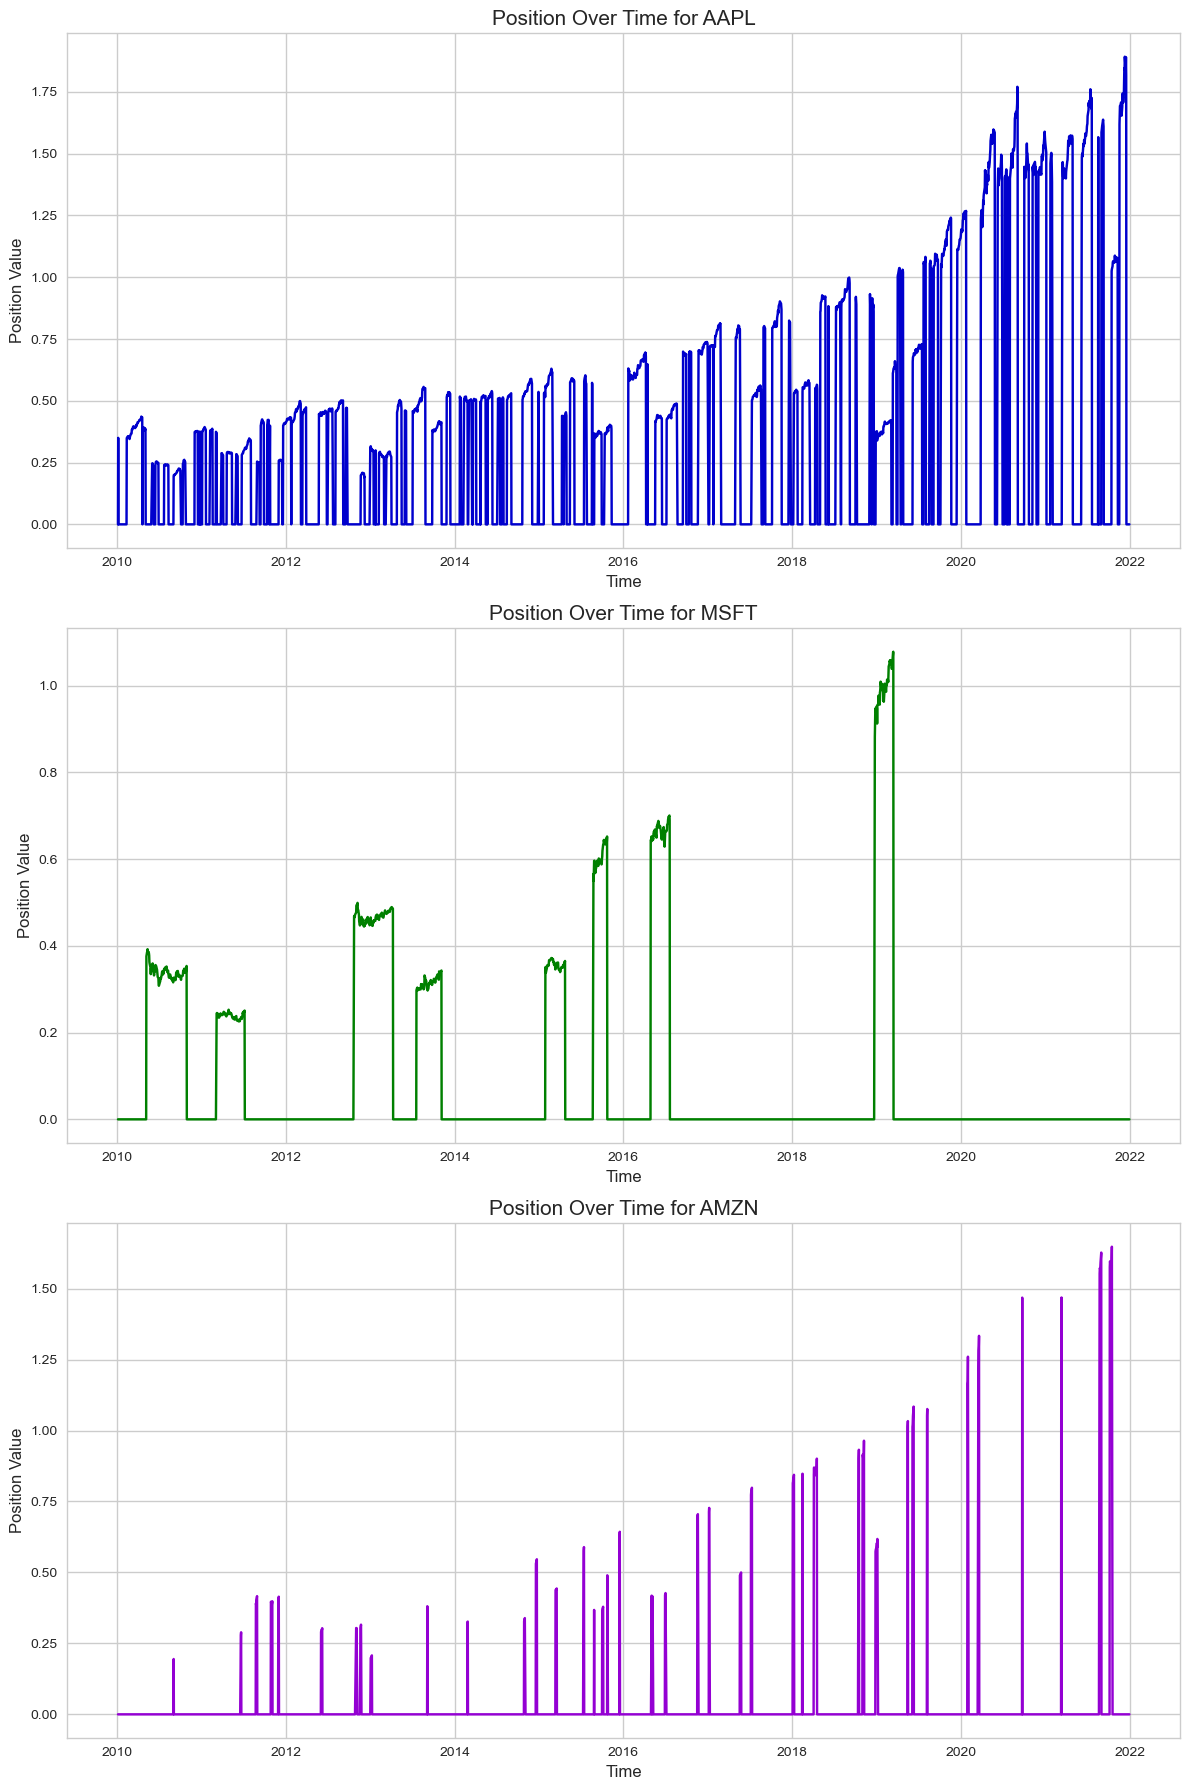

In [19]:
# COMPUTE MEANINGFUL PLOTS OF YOUR STRATEGY AND LABEL IT IN AN UNDERSTANDABLE WAY

# Set the style for nice-looking plots
plt.style.use('seaborn')
plt.style.use('seaborn-whitegrid')

# Portfolio value over time
df_position.sum(axis = 1).plot(figsize = (12,8))
plt.title('Portfolio Value Over Time', fontsize = 15)
plt.xlabel('Time', fontsize = 12)
plt.ylabel('Value', fontsize = 12)
plt.grid(True)
plt.show()

# Individual asset positions over time
colors = ['mediumblue', 'green', 'darkviolet']

fig, axs = plt.subplots(3, 1, figsize = (12,18))

for i, ticker in enumerate(tickers[:-1]):
    axs[i].plot(df_position[ticker], color = colors[i])
    axs[i].set_title('Position Over Time for ' + ticker, fontsize = 15)
    axs[i].set_xlabel('Time', fontsize = 12)
    axs[i].set_ylabel('Position Value', fontsize = 12)
    axs[i].grid(True)

plt.tight_layout()  # To ensure the subplots don't overlap
plt.show()